In [ ]:
# 필요 시에만 설치합니다.
# !pip install -q gym-jsbsim stable-baselines3[extra]


In [ ]:
import os
import time
import numpy as np
import gym                     # JSBSim 환경 등록용
import gym_jsbsim              # gym.register 호출
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

# 로그/모델 디렉터리
curtime = time.strftime("%Y%m%d%H%M", time.localtime())
log_dir = f"./logs/turn_heading_control_ddpg/{curtime}/"
tb_dir  = "./tb_logs/turn_heading_control_ddpg/"
best_dir = f"./best_model_ddpg/{curtime}/"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(os.path.join(log_dir, "eval"), exist_ok=True)
os.makedirs(best_dir, exist_ok=True)

# 환경 ID (예: Heading 제어 태스크)
env_id = "JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"

# 재현성 설정
seed = 41

# 학습용 VecEnv
def make_env():
    env = gym.make(env_id)
    env.seed(seed)
    return env

train_vec = DummyVecEnv([make_env])
train_vec.seed(seed)
train_vec = VecMonitor(train_vec, log_dir)

# 평가용 VecEnv (EvalCallback에서 사용)
eval_vec = DummyVecEnv([make_env])
eval_vec.seed(seed + 1)
eval_vec = VecMonitor(eval_vec, os.path.join(log_dir, "eval"))
    

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Sta

In [ ]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise

# 연속 행동 차원
n_actions = train_vec.action_space.shape[-1]

# 가우시안 액션 노이즈 (탐험 강도 sigma 조절)
action_noise = NormalActionNoise(mean=np.zeros(n_actions),
                                 sigma=0.2 * np.ones(n_actions))

# DDPG 하이퍼파라미터는 JSBSim 난이도에 맞춰 기본값에서 약간 상향 조정
model = DDPG(
    policy="MlpPolicy",
    env=train_vec,
    learning_rate=1e-3,          # 필요시 3e-4 ~ 1e-3 범위에서 조절 권장입니다
    buffer_size=200_000,         # JSBSim은 에피소드가 길어 버퍼를 넉넉히 권장입니다
    learning_starts=10_000,      # 충분히 리플레이 버퍼가 차기 전까지 학습 지연입니다
    batch_size=256,
    tau=0.005,
    gamma=0.9,
    train_freq=(1, "episode"),   # 스텝 단위 학습 원하면 (1, "step")로 변경 가능합니다
    gradient_steps=-1,           # train_freq마다 가능한 만큼 학습입니다
    action_noise=action_noise,
    tensorboard_log=tb_dir,
    verbose=1,
    seed=seed,
    device="auto",
)


Using cpu device


In [3]:
from stable_baselines3.common.callbacks import EvalCallback

eval_callback = EvalCallback(
    eval_env=eval_vec,
    best_model_save_path=best_dir,
    log_path=os.path.join(log_dir, "eval"),
    eval_freq=10_000,        # 학습 속도에 맞춰 조절 가능합니다
    n_eval_episodes=10,
    deterministic=True,
    render=False,
)


In [4]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_


In [ ]:
# 총 스텝 수는 과제 난이도/리소스에 맞게 조절합니다
total_timesteps = 200000

model.learn(
    total_timesteps=total_timesteps,
    callback=eval_callback,
    progress_bar=True,
)

# 최종 모델 저장 (베스트 모델은 콜백이 별도로 저장합니다)
final_model_path = os.path.join(best_dir, "ddpg_final.zip")
model.save(final_model_path)
final_model_path




     JSBSim Flight Dynamics Model v1.1.1 [GitHub build 134/commit c11b0ac53846798bca8f60132ebf8df935e1a802] Jul 31 2025 13:38:21
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Logging to ./tb_logs/turn_heading_control_ddpg/DDPG_4


/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: 
WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to 
rewrite the environment with new step API. 
  logger.deprecation(

/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a 

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 141      |
|    ep_rew_mean     | 38       |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1723     |
|    time_elapsed    | 0        |
|    total_timesteps | 565      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 138      |
|    ep_rew_mean     | 37.6     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2150     |
|    time_elapsed    | 0        |
|    total_timesteps | 1100     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 123      |
|    ep_rew_mean     | 34       |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2268     |
|    time_elapsed    | 0        |
|    total_timesteps | 1475     |
--------------

Eval num_timesteps=10000, episode_reward=18.61 +/- 2.99

Episode length: 60.50 +/- 1.50

---------------------------------
| eval/              |          |
|    mean_ep_length  | 60.5     |
|    mean_reward     | 18.6     |
| time/              |          |
|    total_timesteps | 10000    |
---------------------------------


New best mean reward!

'./best_model_ddpg/202508092322/ddpg_final.zip'

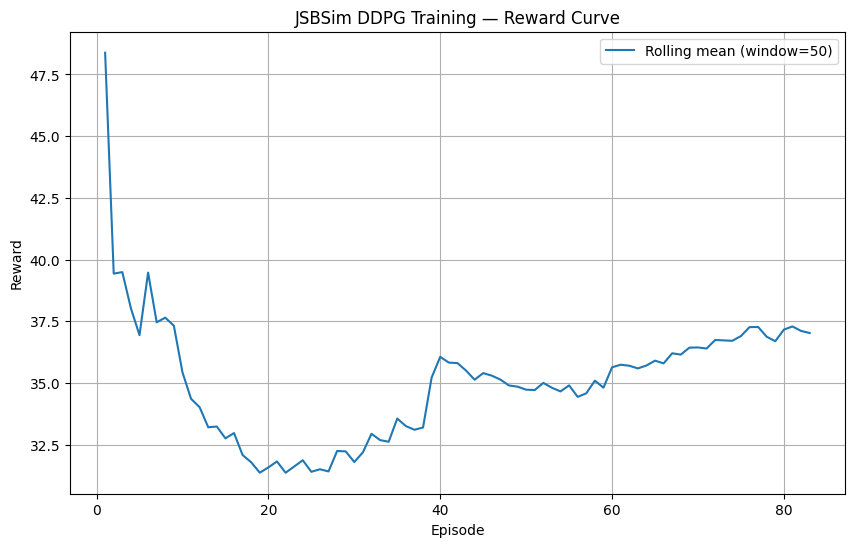

In [6]:
# === JSBSim DDPG 학습 보상 곡선 시각화 ===
# 전제: 학습 셀에서 log_dir, curtime 이 이미 정의돼 있음.
# (필요시 직접: log_dir = f"./logs/jsbsim_ddpg/{curtime}/")

import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 1) 학습 로그 CSV 수집 (eval/ 제외, 하위 폴더까지 검색)
files = glob.glob(str(Path(log_dir) / "monitor*.csv"))
if not files:
    files = glob.glob(str(Path(log_dir) / "**/monitor*.csv"), recursive=True)
files = [f for f in files if "eval" not in f]

if not files:
    raise FileNotFoundError(f"monitor*.csv not found under {log_dir}")

# 2) 여러 CSV를 하나의 에피소드 시퀀스로 병합
dfs = []
for f in sorted(files):
    df = pd.read_csv(f, comment="#")     # SB3 Monitor: columns r(리턴), l(길이), t(시간)
    dfs.append(df[["r", "l", "t"]])
data = pd.concat(dfs, ignore_index=True)
data["episode"] = range(1, len(data) + 1)

# 3) 롤링 평균 보상 계산
window = 50  # 필요시 조정
data["rolling_reward"] = data["r"].rolling(window=window, min_periods=1).mean()

# 4) 시각화
plt.figure(figsize=(10, 6))
plt.plot(data["episode"], data["rolling_reward"], label=f"Rolling mean (window={window})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("JSBSim DDPG Training — Reward Curve")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
from stable_baselines3.common.evaluation import evaluate_policy

# 콜백이 저장한 베스트 모델이 있으면 우선 사용합니다
best_model_file = os.path.join(best_dir, "best_model.zip")
model_to_eval = DDPG.load(best_model_file, env=eval_vec) if os.path.exists(best_model_file) else DDPG.load(final_model_path, env=eval_vec)

mean_reward, std_reward = evaluate_policy(
    model_to_eval, 
    eval_vec, 
    n_eval_episodes=20, 
    deterministic=True, 
    render=False,
)
print(f"[DDPG] 평균 보상: {mean_reward:.2f} ± {std_reward:.2f} 입니다")


/mnt/d/2025_cansat_ai/venva/lib/python3.10/site-packages/gym_jsbsim/environment.py:162: UserWarning: WARN: Could not seed environment <NoFGJsbSimEnv<JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0>>
  gym.logger.warn("Could not seed environment %s", self)


[DDPG] 평균 보상: 18.27 ± 2.26 입니다


In [8]:
# VecEnv에서 단일 에피소드 롤아웃 예시입니다
obs = eval_vec.reset()
done = [False]
episode_reward = 0.0

while not done[0]:
    action, _ = model_to_eval.predict(obs, deterministic=True)
    obs, reward, done, info = eval_vec.step(action)
    episode_reward += reward[0]

print(f"테스트 에피소드 보상: {episode_reward:.2f} 입니다")


테스트 에피소드 보상: 23.34 입니다
